In [36]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#load
df = pd.read_csv(r"C:\Users\Amira\Downloads\Project3_AML\PS_20174392719_1491204439457_log.csv")

In [37]:
print(df.shape)
print(df.head())
print(df.info())

(6362620, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11

In [38]:
#missing values
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_percent = (
    (missing / len(df)) * 100
).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percent": missing_percent
})

missing_df

#duplicates
duplicate_rows = df.duplicated().sum()

print("Duplicate Rows:", duplicate_rows)

Duplicate Rows: 0


In [39]:
#transaction type distribution
transaction_type_counts = df["type"].value_counts()

transaction_type_counts

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [40]:
#AML/Fraud compliance risk flags

#high-value trans flag
high_value_threshold = df["amount"].quantile(0.95)

df["high_value_flag"] = df["amount"] >= high_value_threshold

print("High Value Threshold:", high_value_threshold)
print("High Value Transactions:", df["high_value_flag"].sum())

#very high flag
very_high_value_threshold = df["amount"].quantile(0.99)

df["very_high_value_flag"] = df["amount"] >= very_high_value_threshold

print("Very High Value Threshold:", very_high_value_threshold)
print("Very High Value Transactions:", df["very_high_value_flag"].sum())

#full balance drain flag
df["full_balance_drain_flag"] = (
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["amount"] > 0)
)

df["full_balance_drain_flag"].sum()

#balance inconsistency flag
df["origin_balance_error"] = (
    (df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]).abs()
)

df["origin_balance_inconsistency_flag"] = (
    df["origin_balance_error"] > 0.01
)

df["origin_balance_inconsistency_flag"].sum()

#destination flag
df["destination_balance_error"] = (
    (df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]).abs()
)

df["destination_balance_inconsistency_flag"] = (
    df["destination_balance_error"] > 0.01
)

df["destination_balance_inconsistency_flag"].sum()

High Value Threshold: 518634.19649999996
High Value Transactions: 318131
Very High Value Threshold: 1615979.4715999917
Very High Value Transactions: 63627


np.int64(4188647)

In [41]:
##======TRANSACTION RISK SCORING======##

#compliance score
df["compliance_risk_score"] = 0

df.loc[df["high_value_flag"], "compliance_risk_score"] += 2
df.loc[df["very_high_value_flag"], "compliance_risk_score"] += 3
df.loc[df["full_balance_drain_flag"], "compliance_risk_score"] += 3
df.loc[df["origin_balance_inconsistency_flag"], "compliance_risk_score"] += 2
df.loc[df["destination_balance_inconsistency_flag"], "compliance_risk_score"] += 2
df.loc[df["type"].isin(["TRANSFER", "CASH_OUT"]), "compliance_risk_score"] += 2

#risk classification
def compliance_risk_level(score):

    if score <= 2:
        return "Low"

    elif score <= 5:
        return "Medium"

    elif score <= 8:
        return "High"

    else:
        return "Critical"

df["compliance_risk_level"] = (
    df["compliance_risk_score"]
    .apply(compliance_risk_level)
)

#review results
df[[
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "high_value_flag",
    "full_balance_drain_flag",
    "compliance_risk_score",
    "compliance_risk_level",
    "isFraud",
    "isFlaggedFraud"
]].head(10)

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,high_value_flag,full_balance_drain_flag,compliance_risk_score,compliance_risk_level,isFraud,isFlaggedFraud
0,PAYMENT,9839.64,170136.00,160296.36,0.0,0.00,False,False,2,Low,0,0
1,PAYMENT,1864.28,21249.00,19384.72,0.0,0.00,False,False,2,Low,0,0
2,TRANSFER,181.00,181.00,0.00,0.0,0.00,False,True,7,High,1,0
3,CASH_OUT,181.00,181.00,0.00,21182.0,0.00,False,True,7,High,1,0
4,PAYMENT,11668.14,41554.00,29885.86,0.0,0.00,False,False,2,Low,0,0
5,PAYMENT,7817.71,53860.00,46042.29,0.0,0.00,False,False,2,Low,0,0
6,PAYMENT,7107.77,183195.00,176087.23,0.0,0.00,False,False,2,Low,0,0
7,PAYMENT,7861.64,176087.23,168225.59,0.0,0.00,False,False,2,Low,0,0
8,PAYMENT,4024.36,2671.00,0.00,0.0,0.00,False,True,7,High,0,0
9,DEBIT,5337.77,41720.00,36382.23,41898.0,40348.79,False,False,2,Low,0,0


In [42]:
#Compliance monitoring control testing

#monitoring controls
df["ctrl_transaction_type_present"] = df["type"].notna()

df["ctrl_amount_positive"] = df["amount"] > 0

df["ctrl_origin_account_present"] = df["nameOrig"].notna()

df["ctrl_destination_account_present"] = df["nameDest"].notna()

df["ctrl_origin_balance_valid"] = (
    df["oldbalanceOrg"].notna() &
    df["newbalanceOrig"].notna()
)

df["ctrl_destination_balance_valid"] = (
    df["oldbalanceDest"].notna() &
    df["newbalanceDest"].notna()
)

df["ctrl_fraud_flag_present"] = df["isFraud"].notna()

df["ctrl_system_flag_present"] = df["isFlaggedFraud"].notna()

#automated control testing summary
control_tests = {
    "CTRL-001 Transaction Type Present": "ctrl_transaction_type_present",
    "CTRL-002 Positive Transaction Amount": "ctrl_amount_positive",
    "CTRL-003 Origin Account Present": "ctrl_origin_account_present",
    "CTRL-004 Destination Account Present": "ctrl_destination_account_present",
    "CTRL-005 Origin Balance Fields Present": "ctrl_origin_balance_valid",
    "CTRL-006 Destination Balance Fields Present": "ctrl_destination_balance_valid",
    "CTRL-007 Fraud Label Present": "ctrl_fraud_flag_present",
    "CTRL-008 System Flag Present": "ctrl_system_flag_present"
}

control_results = []

for control_name, rule_col in control_tests.items():

    total_tested = len(df)
    passed = df[rule_col].sum()
    failed = total_tested - passed
    pass_rate = round((passed / total_tested) * 100, 2)

    if pass_rate >= 95:
        effectiveness = "Effective"
    elif pass_rate >= 85:
        effectiveness = "Needs Monitoring"
    else:
        effectiveness = "Ineffective"

    control_results.append({
        "Control": control_name,
        "Total Tested": total_tested,
        "Passed": passed,
        "Failed": failed,
        "Pass Rate %": pass_rate,
        "Effectiveness": effectiveness
    })

control_summary_df = pd.DataFrame(control_results)

control_summary_df


,Control,Total Tested,Passed,Failed,Pass Rate %,Effectiveness
0,CTRL-001 Transaction Type Present,6362620,6362620,0,100.0,Effective
1,CTRL-002 Positive Transaction Amount,6362620,6362604,16,100.0,Effective
2,CTRL-003 Origin Account Present,6362620,6362620,0,100.0,Effective
3,CTRL-004 Destination Account Present,6362620,6362620,0,100.0,Effective
4,CTRL-005 Origin Balance Fields Present,6362620,6362620,0,100.0,Effective
5,CTRL-006 Destination Balance Fields Present,6362620,6362620,0,100.0,Effective
6,CTRL-007 Fraud Label Present,6362620,6362620,0,100.0,Effective
7,CTRL-008 System Flag Present,6362620,6362620,0,100.0,Effective


In [43]:
##======KPIs======##

#kpi calc
total_transactions = len(df)

total_fraud = int(df["isFraud"].sum())

system_flagged = int(df["isFlaggedFraud"].sum())

high_risk_transactions = len(
    df[df["compliance_risk_level"] == "High"]
)

critical_risk_transactions = len(
    df[df["compliance_risk_level"] == "Critical"]
)

high_value_transactions = int(df["high_value_flag"].sum())

full_balance_drains = int(df["full_balance_drain_flag"].sum())

fraud_detection_rate = round(
    system_flagged / total_fraud * 100,
    2
) if total_fraud > 0 else 0

print("Total Transactions:", total_transactions)
print("Total Fraud Transactions:", total_fraud)
print("System Flagged Fraud:", system_flagged)
print("Fraud Detection Rate:", fraud_detection_rate)
print("High Risk Transactions:", high_risk_transactions)
print("Critical Risk Transactions:", critical_risk_transactions)
print("High Value Transactions:", high_value_transactions)
print("Full Balance Drains:", full_balance_drains)

Total Transactions: 6362620
Total Fraud Transactions: 8213
System Flagged Fraud: 16
Fraud Detection Rate: 0.19
High Risk Transactions: 1588214
Critical Risk Transactions: 390963
High Value Transactions: 318131
Full Balance Drains: 1520581


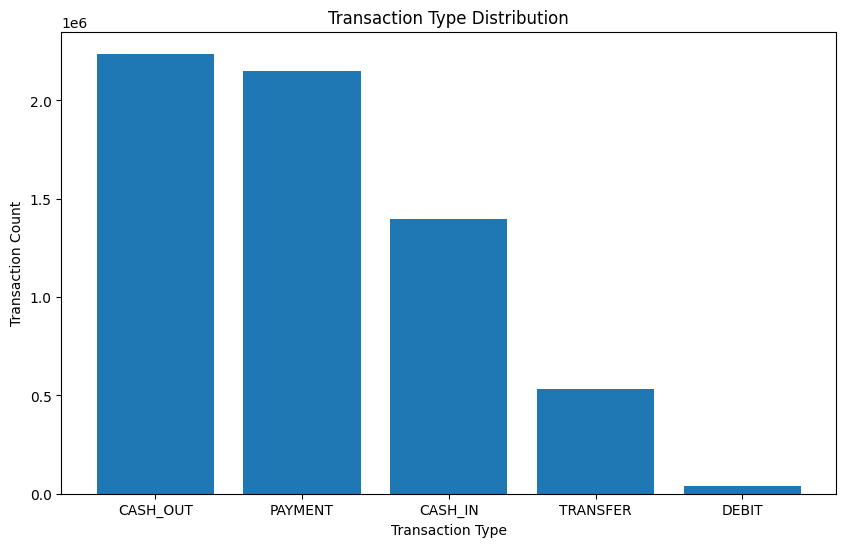

In [44]:
#trans type distribution
type_counts = df["type"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    type_counts.index,
    type_counts.values
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Count")

plt.show()

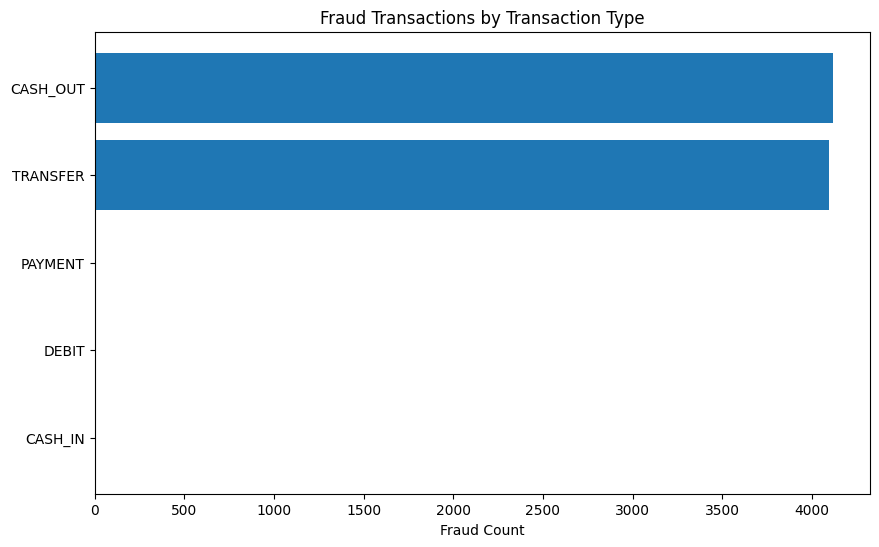

In [45]:
#fraud by trans type
fraud_by_type = (
    df.groupby("type")["isFraud"]
      .sum()
      .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    fraud_by_type.index,
    fraud_by_type.values
)

plt.title("Fraud Transactions by Transaction Type")
plt.xlabel("Fraud Count")

plt.show()

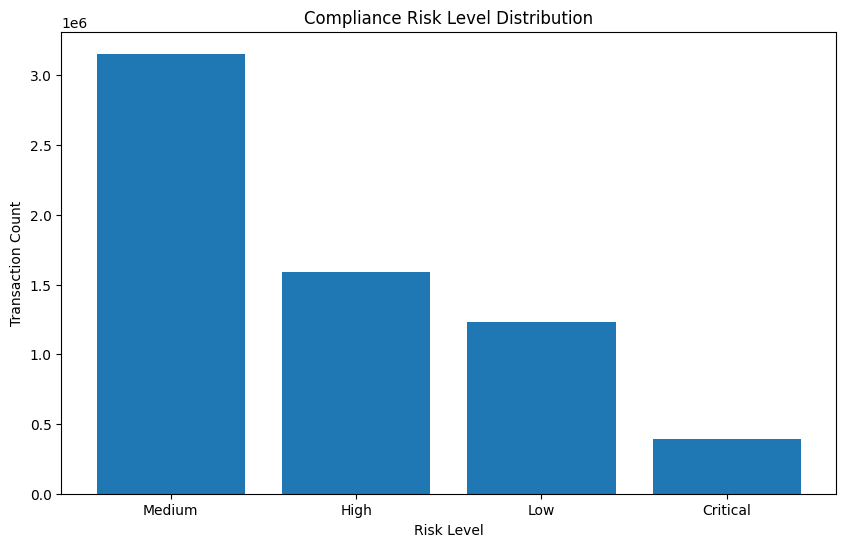

In [46]:
#compliance risk level dist
risk_counts = df["compliance_risk_level"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.title("Compliance Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Transaction Count")

plt.show()

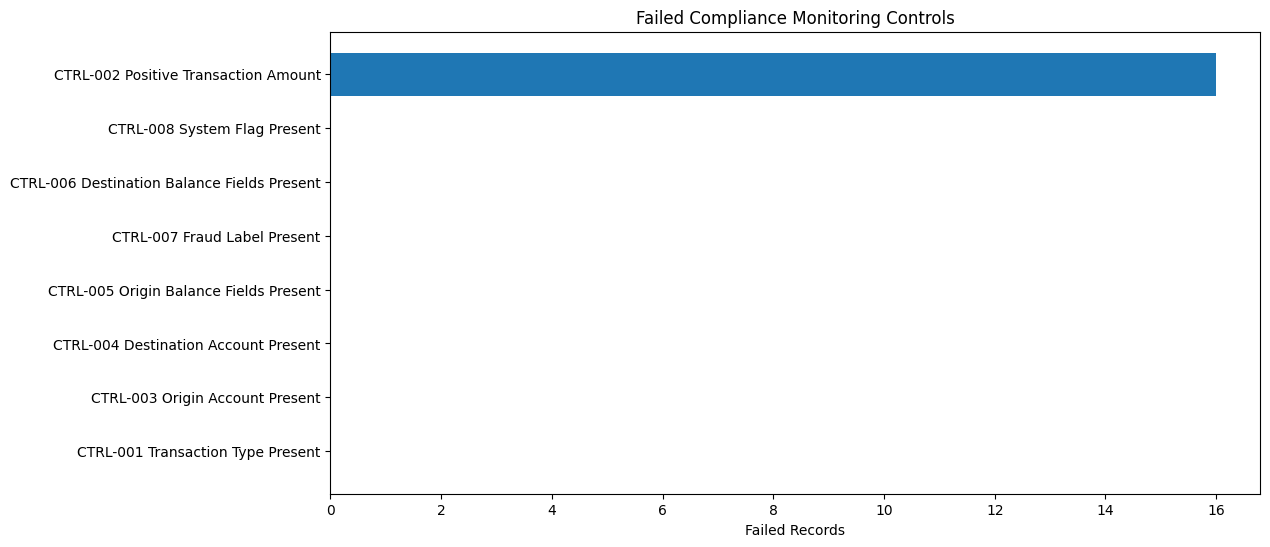

In [47]:
#failed control counts
failed_control_chart = (
    control_summary_df
    .sort_values("Failed", ascending=True)
)

plt.figure(figsize=(12, 6))

plt.barh(
    failed_control_chart["Control"],
    failed_control_chart["Failed"]
)

plt.title("Failed Compliance Monitoring Controls")
plt.xlabel("Failed Records")

plt.show()

## AML and Fraud Compliance Monitoring Framework

This project simulates a regulatory compliance monitoring framework for financial transactions using fraud and transaction activity data.

The monitoring framework evaluates transactions for high-value activity, full-balance drains, balance inconsistencies, high-risk transaction types, and system fraud flagging effectiveness. These indicators are used to assign compliance risk scores and classify transactions into Low, Medium, High, and Critical risk categories.

The purpose of this framework is to support AML and fraud compliance teams by identifying transactions that may require enhanced review, escalation, or remediation. The control testing section evaluates whether key transaction data fields are complete and suitable for compliance monitoring.

This project demonstrates how transaction monitoring data can be transformed into a governance, risk, and compliance reporting system.

---

In [48]:
#alert register

#alert trigger logic
df["alert_triggered"] = (
    (df["compliance_risk_level"].isin(["High", "Critical"])) |
    (df["isFraud"] == 1) |
    (df["isFlaggedFraud"] == 1) |
    (df["very_high_value_flag"] == True) |
    (df["full_balance_drain_flag"] == True)
)

df["alert_triggered"].value_counts()

#alert type
def assign_alert_type(row):

    if row["isFraud"] == 1 and row["isFlaggedFraud"] == 0:
        return "Missed Fraud Alert"

    elif row["isFlaggedFraud"] == 1:
        return "System Fraud Alert"

    elif row["very_high_value_flag"] == True:
        return "Very High-Value Transaction"

    elif row["full_balance_drain_flag"] == True:
        return "Full Balance Drain"

    elif row["origin_balance_inconsistency_flag"] == True:
        return "Origin Balance Inconsistency"

    elif row["destination_balance_inconsistency_flag"] == True:
        return "Destination Balance Inconsistency"

    elif row["type"] in ["TRANSFER", "CASH_OUT"]:
        return "High-Risk Transaction Type"

    else:
        return "General Compliance Review"


df["alert_type"] = df.apply(assign_alert_type, axis=1)

#alert priority
def assign_alert_priority(row):

    if row["isFraud"] == 1 and row["isFlaggedFraud"] == 0:
        return "Critical"

    elif row["compliance_risk_level"] == "Critical":
        return "Critical"

    elif row["isFlaggedFraud"] == 1:
        return "High"

    elif row["compliance_risk_level"] == "High":
        return "High"

    elif row["very_high_value_flag"] == True:
        return "Medium"

    else:
        return "Low"


df["alert_priority"] = df.apply(assign_alert_priority, axis=1)

#alert owner
def assign_alert_owner(row):

    if row["alert_type"] == "Missed Fraud Alert":
        return "Fraud Compliance Team"

    elif row["alert_type"] == "System Fraud Alert":
        return "Fraud Operations Team"

    elif row["alert_type"] == "Very High-Value Transaction":
        return "AML Review Team"

    elif row["alert_type"] == "Full Balance Drain":
        return "Financial Crime Monitoring"

    elif "Balance Inconsistency" in row["alert_type"]:
        return "Transaction Monitoring QA"

    elif row["type"] in ["TRANSFER", "CASH_OUT"]:
        return "AML Review Team"

    else:
        return "Compliance Monitoring Team"


df["alert_owner"] = df.apply(assign_alert_owner, axis=1)

#alert status
def assign_alert_status(row):

    if row["alert_priority"] == "Critical":
        return "Escalated"

    elif row["alert_priority"] == "High":
        return "Under Investigation"

    elif row["alert_priority"] == "Medium":
        return "Pending Review"

    else:
        return "Monitoring"


df["alert_status"] = df.apply(assign_alert_status, axis=1)

#remediation
def assign_review_action(row):

    if row["alert_type"] == "Missed Fraud Alert":
        return "Review monitoring rule failure and escalate for fraud investigation"

    elif row["alert_type"] == "System Fraud Alert":
        return "Validate system fraud flag and complete fraud case review"

    elif row["alert_type"] == "Very High-Value Transaction":
        return "Perform enhanced due diligence and source-of-funds review"

    elif row["alert_type"] == "Full Balance Drain":
        return "Investigate potential account takeover or unauthorized transfer"

    elif row["alert_type"] == "Origin Balance Inconsistency":
        return "Review origin balance calculation and transaction integrity"

    elif row["alert_type"] == "Destination Balance Inconsistency":
        return "Review destination balance movement and transaction posting accuracy"

    elif row["alert_type"] == "High-Risk Transaction Type":
        return "Perform AML transaction review for high-risk movement pattern"

    else:
        return "Maintain standard compliance monitoring"


df["review_action"] = df.apply(assign_review_action, axis=1)

#alert register
alert_register = df[df["alert_triggered"] == True].copy()

alert_register = alert_register[[
    "step",
    "type",
    "amount",
    "nameOrig",
    "oldbalanceOrg",
    "newbalanceOrig",
    "nameDest",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud",
    "high_value_flag",
    "very_high_value_flag",
    "full_balance_drain_flag",
    "origin_balance_inconsistency_flag",
    "destination_balance_inconsistency_flag",
    "compliance_risk_score",
    "compliance_risk_level",
    "alert_type",
    "alert_priority",
    "alert_owner",
    "alert_status",
    "review_action"
]]

alert_register.head()

#alert register summary
print("Total Transactions:", len(df))
print("Total Alerts Triggered:", len(alert_register))
print("Alert Rate:", round((len(alert_register) / len(df)) * 100, 2), "%")

alert_register[[
    "alert_type",
    "alert_priority",
    "alert_owner",
    "alert_status"
]].value_counts().head(20)

#save
from pathlib import Path

Path("outputs/tables").mkdir(
    parents=True,
    exist_ok=True
)

alert_register.to_csv(
    "outputs/tables/aml_fraud_alert_register.csv",
    index=False
)

print("AML/Fraud alert register saved successfully.")

Total Transactions: 6362620
Total Alerts Triggered: 1985367
Alert Rate: 31.2 %
AML/Fraud alert register saved successfully.


In [49]:
##======ALERT KPIs======##
total_alerts = len(alert_register)

critical_alerts = len(
    alert_register[alert_register["alert_priority"] == "Critical"]
)

high_alerts = len(
    alert_register[alert_register["alert_priority"] == "High"]
)

missed_fraud_alerts = len(
    alert_register[alert_register["alert_type"] == "Missed Fraud Alert"]
)

system_fraud_alerts = len(
    alert_register[alert_register["alert_type"] == "System Fraud Alert"]
)

avg_alert_amount = round(
    alert_register["amount"].mean(),
    2
)

print("Total Alerts:", total_alerts)
print("Critical Alerts:", critical_alerts)
print("High Alerts:", high_alerts)
print("Missed Fraud Alerts:", missed_fraud_alerts)
print("System Fraud Alerts:", system_fraud_alerts)
print("Average Alert Amount:", avg_alert_amount)

Total Alerts: 1985367
Critical Alerts: 396162
High Alerts: 1584900
Missed Fraud Alerts: 8197
System Fraud Alerts: 16
Average Alert Amount: 365532.44


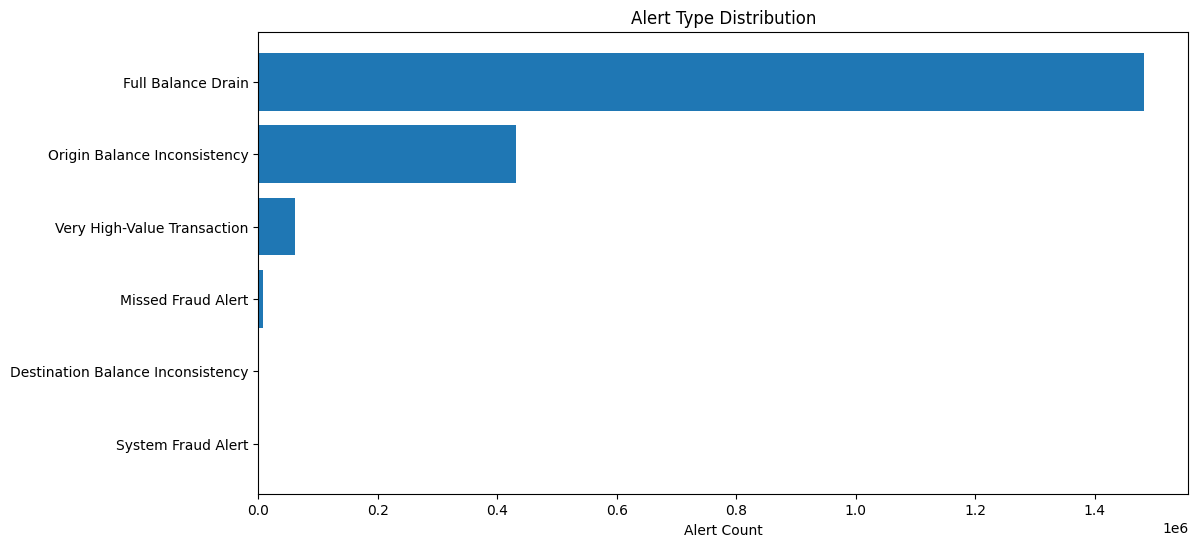

In [50]:
#alert type dist
alert_type_counts = (
    alert_register["alert_type"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 6))

plt.barh(
    alert_type_counts.index,
    alert_type_counts.values
)

plt.title("Alert Type Distribution")
plt.xlabel("Alert Count")

plt.show()

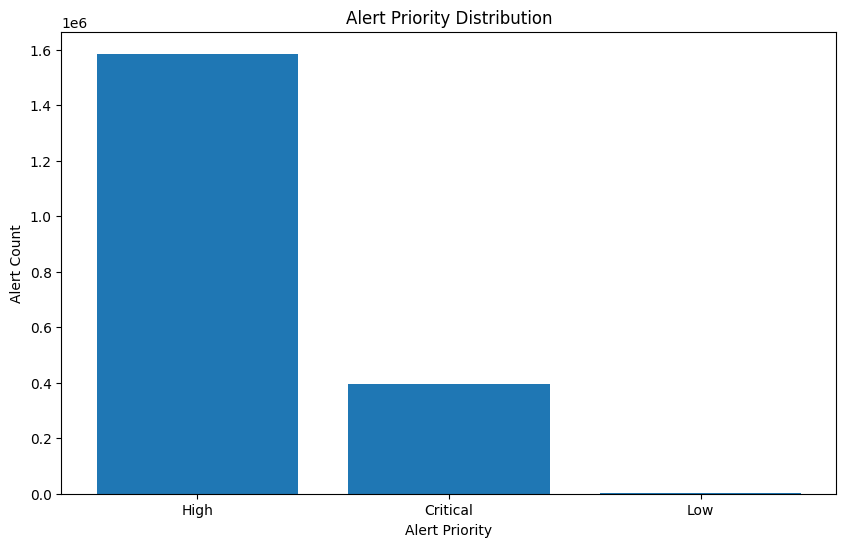

In [51]:
#alert priority dist
priority_counts = (
    alert_register["alert_priority"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    priority_counts.index,
    priority_counts.values
)

plt.title("Alert Priority Distribution")
plt.xlabel("Alert Priority")
plt.ylabel("Alert Count")

plt.show()

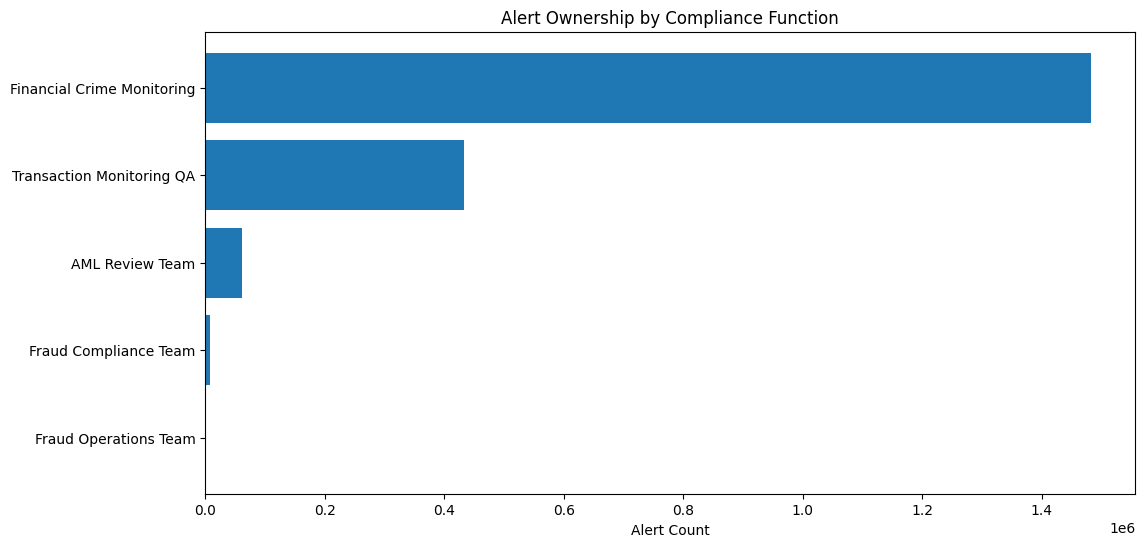

In [52]:
#alert owner workload
owner_counts = (
    alert_register["alert_owner"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 6))

plt.barh(
    owner_counts.index,
    owner_counts.values
)

plt.title("Alert Ownership by Compliance Function")
plt.xlabel("Alert Count")

plt.show()

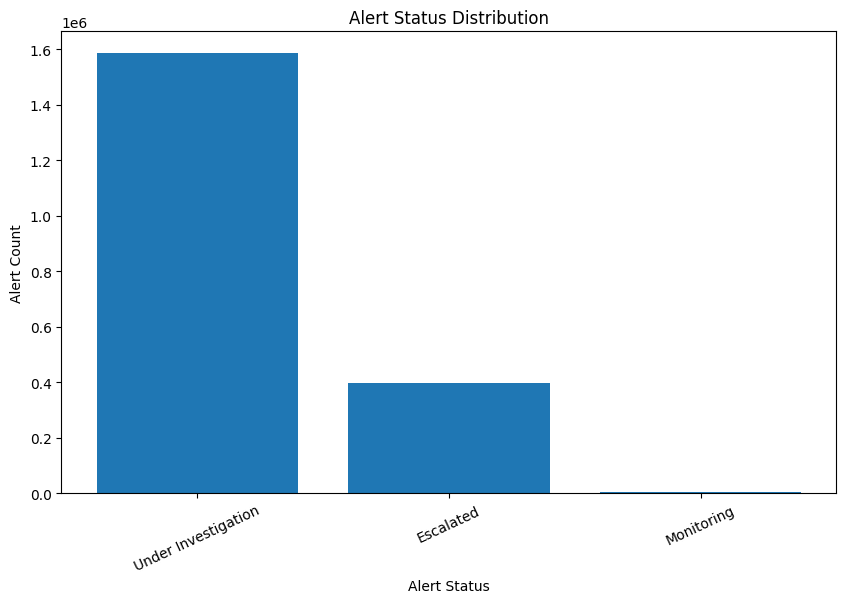

In [53]:
#alert status dist
status_counts = (
    alert_register["alert_status"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    status_counts.index,
    status_counts.values
)

plt.title("Alert Status Distribution")
plt.xlabel("Alert Status")
plt.ylabel("Alert Count")

plt.xticks(rotation=25)

plt.show()

In [54]:
#missed fraud alerts
missed_fraud_register = alert_register[
    alert_register["alert_type"] == "Missed Fraud Alert"
].copy()

missed_fraud_register[[
    "step",
    "type",
    "amount",
    "nameOrig",
    "nameDest",
    "isFraud",
    "isFlaggedFraud",
    "compliance_risk_score",
    "compliance_risk_level",
    "alert_priority",
    "review_action"
]].head()

#save
missed_fraud_register.to_csv(
    "outputs/tables/missed_fraud_alert_register.csv",
    index=False
)

print("Missed fraud alert register saved successfully.")

Missed fraud alert register saved successfully.


## AML/Fraud Alert Register

An alert register was created to simulate an enterprise AML and fraud compliance monitoring workflow. Transactions were flagged for review when they met high-risk criteria such as actual fraud labels, system fraud flags, very high transaction amounts, full-balance drains, high compliance risk scores, or balance inconsistencies.

Each alert was assigned an alert type, priority level, compliance owner, investigation status, and recommended review action. This structure mirrors real compliance operations where suspicious activity is routed to specialized teams for review, escalation, and remediation.

Critical alerts include transactions where actual fraud was not flagged by the system, high-risk transactions, or transactions requiring immediate review due to potential monitoring gaps. These alerts are especially important because they may indicate control weaknesses in fraud detection or AML monitoring rules.

The alert register supports:

- suspicious activity monitoring
- fraud escalation
- AML review workflows
- compliance ownership
- monitoring quality assurance
- audit readiness
- executive reporting

---

In [55]:
##======FRAUD DETECTION ANALYSIS======##

#detection outcome categories
def fraud_detection_outcome(row):

    if row["isFraud"] == 1 and row["isFlaggedFraud"] == 1:
        return "True Positive"

    elif row["isFraud"] == 1 and row["isFlaggedFraud"] == 0:
        return "Missed Fraud"

    elif row["isFraud"] == 0 and row["isFlaggedFraud"] == 1:
        return "False Positive"

    else:
        return "True Negative"


df["fraud_detection_outcome"] = df.apply(
    fraud_detection_outcome,
    axis=1
)

#outcome counts
detection_counts = (
    df["fraud_detection_outcome"]
    .value_counts()
)

detection_counts

fraud_detection_outcome
True Negative    6354407
Missed Fraud        8197
True Positive         16
Name: count, dtype: int64

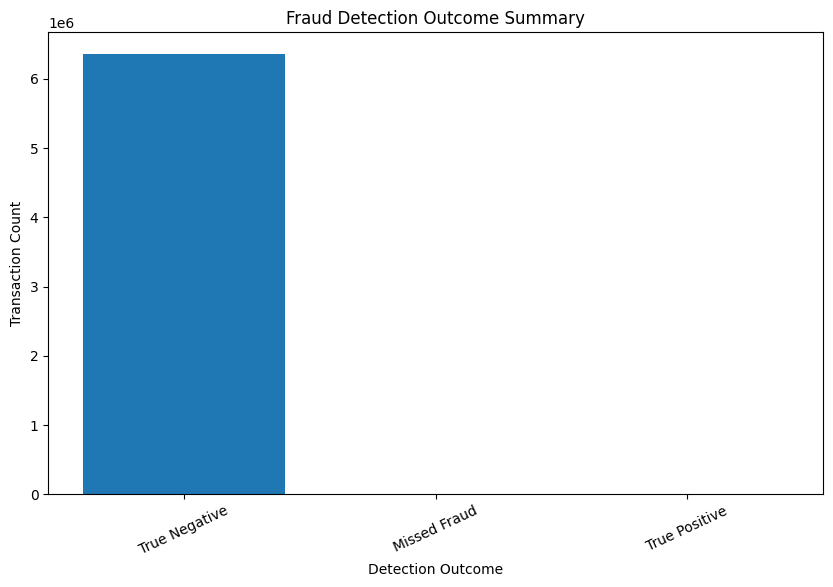

In [56]:
#outcome visualization
plt.figure(figsize=(10, 6))

plt.bar(
    detection_counts.index,
    detection_counts.values
)

plt.title("Fraud Detection Outcome Summary")
plt.xlabel("Detection Outcome")
plt.ylabel("Transaction Count")

plt.xticks(rotation=25)

plt.show()

In [57]:
#confusion matrix components
true_positive = len(
    df[
        (df["isFraud"] == 1) &
        (df["isFlaggedFraud"] == 1)
    ]
)

missed_fraud = len(
    df[
        (df["isFraud"] == 1) &
        (df["isFlaggedFraud"] == 0)
    ]
)

false_positive = len(
    df[
        (df["isFraud"] == 0) &
        (df["isFlaggedFraud"] == 1)
    ]
)

true_negative = len(
    df[
        (df["isFraud"] == 0) &
        (df["isFlaggedFraud"] == 0)
    ]
)

print("True Positive:", true_positive)
print("Missed Fraud:", missed_fraud)
print("False Positive:", false_positive)
print("True Negative:", true_negative)

True Positive: 16
Missed Fraud: 8197
False Positive: 0
True Negative: 6354407


In [58]:
#compliance monitoring metrics
total_actual_fraud = true_positive + missed_fraud
total_system_flagged = true_positive + false_positive

detection_rate = round(
    (true_positive / total_actual_fraud) * 100,
    2
) if total_actual_fraud > 0 else 0

missed_fraud_rate = round(
    (missed_fraud / total_actual_fraud) * 100,
    2
) if total_actual_fraud > 0 else 0

false_positive_rate = round(
    (false_positive / total_system_flagged) * 100,
    2
) if total_system_flagged > 0 else 0

system_flag_rate = round(
    (total_system_flagged / len(df)) * 100,
    4
)

actual_fraud_rate = round(
    (total_actual_fraud / len(df)) * 100,
    4
)

print("Actual Fraud Rate:", actual_fraud_rate, "%")
print("System Flag Rate:", system_flag_rate, "%")
print("Detection Rate:", detection_rate, "%")
print("Missed Fraud Rate:", missed_fraud_rate, "%")
print("False Positive Rate:", false_positive_rate, "%")

Actual Fraud Rate: 0.1291 %
System Flag Rate: 0.0003 %
Detection Rate: 0.19 %
Missed Fraud Rate: 99.81 %
False Positive Rate: 0.0 %


In [59]:
##Detection gap summary table

#gap analysis table
fraud_gap_summary = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Actual Fraud Transactions",
        "System Flagged Transactions",
        "True Positives",
        "Missed Fraud",
        "False Positives",
        "True Negatives",
        "Actual Fraud Rate %",
        "System Flag Rate %",
        "Detection Rate %",
        "Missed Fraud Rate %",
        "False Positive Rate %"
    ],
    "Value": [
        len(df),
        total_actual_fraud,
        total_system_flagged,
        true_positive,
        missed_fraud,
        false_positive,
        true_negative,
        actual_fraud_rate,
        system_flag_rate,
        detection_rate,
        missed_fraud_rate,
        false_positive_rate
    ]
})

fraud_gap_summary

#save
from pathlib import Path

Path("outputs/tables").mkdir(
    parents=True,
    exist_ok=True
)

fraud_gap_summary.to_csv(
    "outputs/tables/fraud_detection_gap_summary.csv",
    index=False
)

print("Fraud detection gap summary saved successfully.")

Fraud detection gap summary saved successfully.


In [60]:
##Missed fraud exposure analysis

#missed fraud dollar exposure
missed_fraud_df = df[
    (df["isFraud"] == 1) &
    (df["isFlaggedFraud"] == 0)
].copy()

missed_fraud_amount = round(
    missed_fraud_df["amount"].sum(),
    2
)

avg_missed_fraud_amount = round(
    missed_fraud_df["amount"].mean(),
    2
)

max_missed_fraud_amount = round(
    missed_fraud_df["amount"].max(),
    2
)

print("Total Missed Fraud Exposure:", missed_fraud_amount)
print("Average Missed Fraud Amount:", avg_missed_fraud_amount)
print("Largest Missed Fraud Amount:", max_missed_fraud_amount)

Total Missed Fraud Exposure: 11978629864.15
Average Missed Fraud Amount: 1461343.16
Largest Missed Fraud Amount: 10000000.0


In [61]:
#missed fraud by trans type
missed_fraud_by_type = (
    missed_fraud_df
    .groupby("type")["amount"]
    .agg(["count", "sum", "mean", "max"])
    .sort_values("sum", ascending=False)
)

missed_fraud_by_type

,count,sum,mean,max
type,,,,
TRANSFER,4081,5.989428e+09,1.467637e+06,10000000.0
CASH_OUT,4116,5.989202e+09,1.455103e+06,10000000.0


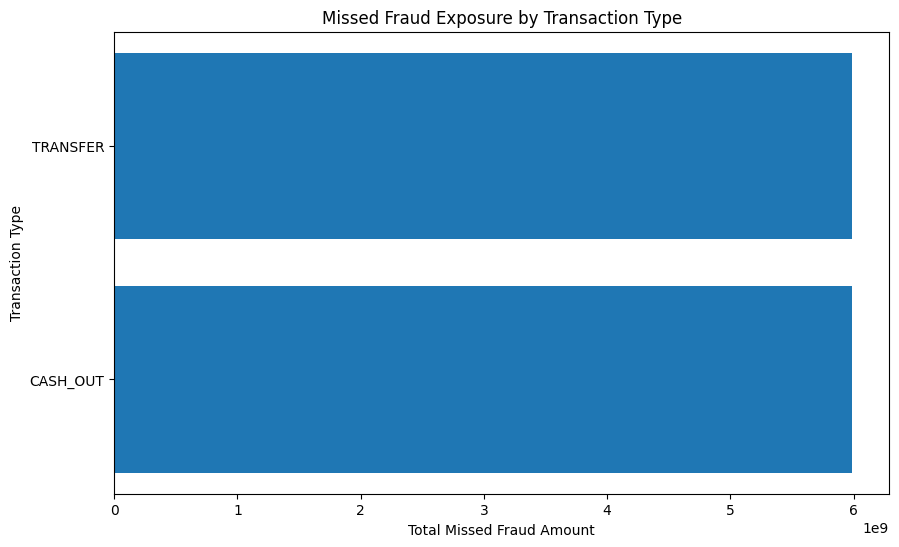

In [62]:
#visual
missed_fraud_type_amount = (
    missed_fraud_df
    .groupby("type")["amount"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    missed_fraud_type_amount.index,
    missed_fraud_type_amount.values
)

plt.title("Missed Fraud Exposure by Transaction Type")
plt.xlabel("Total Missed Fraud Amount")
plt.ylabel("Transaction Type")

plt.show()

In [63]:
#missed fraud register
missed_fraud_register = missed_fraud_df[[
    "step",
    "type",
    "amount",
    "nameOrig",
    "oldbalanceOrg",
    "newbalanceOrig",
    "nameDest",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud",
    "compliance_risk_score",
    "compliance_risk_level",
    "alert_type",
    "alert_priority",
    "alert_owner",
    "alert_status",
    "review_action"
]].copy()

missed_fraud_register.head()

#save
missed_fraud_register.to_csv(
    "outputs/tables/missed_fraud_register.csv",
    index=False
)

print("Missed fraud register saved successfully.")

Missed fraud register saved successfully.


In [64]:
##Monitoring gap risk rating

#control effectiveness
if detection_rate >= 95:
    monitoring_effectiveness = "Effective"

elif detection_rate >= 85:
    monitoring_effectiveness = "Needs Monitoring"

elif detection_rate >= 70:
    monitoring_effectiveness = "Deficient"

else:
    monitoring_effectiveness = "Ineffective"

print("Fraud Monitoring Control Effectiveness:", monitoring_effectiveness)

Fraud Monitoring Control Effectiveness: Ineffective


In [65]:
#monitoring finding
monitoring_finding = pd.DataFrame({
    "Finding ID": ["AML-001"],
    "Finding": ["Fraud monitoring system failed to identify all actual fraud transactions."],
    "Risk Area": ["Fraud Monitoring / AML Compliance"],
    "Severity": [
        "Critical" if monitoring_effectiveness in ["Deficient", "Ineffective"] else "Medium"
    ],
    "Detection Rate %": [detection_rate],
    "Missed Fraud Rate %": [missed_fraud_rate],
    "Missed Fraud Exposure": [missed_fraud_amount],
    "Control Effectiveness": [monitoring_effectiveness],
    "Recommendation": [
        "Enhance fraud detection rules, expand transaction monitoring thresholds, and review missed fraud patterns for model/control tuning."
    ],
    "Owner": ["Fraud Compliance Team"]
})

monitoring_finding

monitoring_finding.to_csv(
    "outputs/tables/fraud_monitoring_audit_finding.csv",
    index=False
)

print("Fraud monitoring audit finding saved successfully.")

Fraud monitoring audit finding saved successfully.


## Fraud Detection Gap Analysis

A fraud detection gap analysis was performed by comparing actual fraud labels against system-generated fraud flags.

The analysis classified each transaction into one of four monitoring outcomes:

- **True Positive**: actual fraud correctly flagged by the system
- **Missed Fraud**: actual fraud not flagged by the system
- **False Positive**: non-fraud transaction incorrectly flagged by the system
- **True Negative**: non-fraud transaction correctly not flagged

This comparison provides insight into the effectiveness of the fraud monitoring control environment. Missed fraud transactions represent potential monitoring gaps because fraudulent transactions occurred without system escalation.

Key monitoring metrics included the fraud detection rate, missed fraud rate, false positive rate, actual fraud rate, and system flag rate.

Missed fraud exposure was also calculated by transaction type to identify where undetected fraud risk was most concentrated. This supports compliance monitoring, rule tuning, control testing, and audit readiness.

The fraud monitoring control effectiveness rating was assigned based on the detection rate. Lower detection rates indicate potential deficiencies in the monitoring framework and may require enhanced detection rules, revised thresholds, or additional fraud typology reviews.

---

### Fraud Monitoring Gap Finding

The fraud detection gap analysis identified actual fraudulent transactions that were not flagged by the system monitoring control. These missed fraud alerts represent a potential control weakness in the transaction monitoring framework.

The missed fraud rate indicates the proportion of fraud activity that bypassed system detection. This creates operational, financial, regulatory, and reputational risk because suspicious transactions may not be escalated for timely review.

Recommended remediation includes enhancing monitoring rules, reviewing missed fraud typologies, recalibrating transaction thresholds, and strengthening quality assurance over fraud detection logic.

---

In [66]:
import numpy as np

# Impact score
df["aml_impact_score"] = np.select(
    [
        df["very_high_value_flag"] == True,
        df["high_value_flag"] == True,
        df["amount"] >= df["amount"].quantile(0.75)
    ],
    [
        4,
        3,
        2
    ],
    default=1
)

# Likelihood score starts at 1
df["aml_likelihood_score"] = 1

df["aml_likelihood_score"] += df["type"].isin(["TRANSFER", "CASH_OUT"]).astype(int)
df["aml_likelihood_score"] += df["full_balance_drain_flag"].astype(int)
df["aml_likelihood_score"] += df["origin_balance_inconsistency_flag"].astype(int)
df["aml_likelihood_score"] += df["destination_balance_inconsistency_flag"].astype(int)

# Cap likelihood score at 4
df["aml_likelihood_score"] = df["aml_likelihood_score"].clip(upper=4)

# Matrix score
df["aml_matrix_score"] = (
    df["aml_impact_score"] * df["aml_likelihood_score"]
)

In [67]:
df["aml_matrix_level"] = np.select(
    [
        df["aml_matrix_score"] <= 3,
        df["aml_matrix_score"] <= 6,
        df["aml_matrix_score"] <= 9
    ],
    [
        "Low",
        "Medium",
        "High"
    ],
    default="Critical"
)

In [68]:
aml_risk_matrix = pd.crosstab(
    df["aml_impact_score"],
    df["aml_likelihood_score"]
)

aml_risk_matrix = aml_risk_matrix.reindex(
    index=[1, 2, 3, 4],
    columns=[1, 2, 3, 4],
    fill_value=0
)

aml_risk_matrix

aml_likelihood_score,1,2,3,4
aml_impact_score,,,,
1,22378,1184722,2432671,1132194
2,1,21115,721779,529629
3,0,777,112435,141292
4,0,10,27287,36330


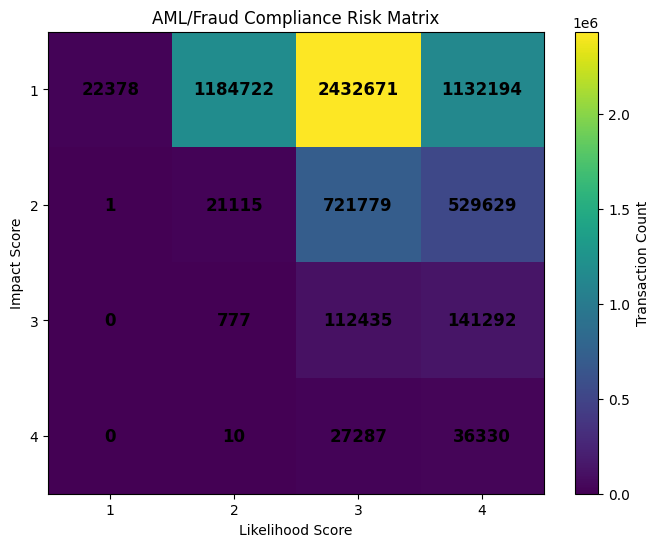

In [69]:
plt.figure(figsize=(8, 6))

plt.imshow(
    aml_risk_matrix,
    aspect="auto"
)

plt.colorbar(label="Transaction Count")

for i in range(aml_risk_matrix.shape[0]):
    for j in range(aml_risk_matrix.shape[1]):
        plt.text(
            j,
            i,
            aml_risk_matrix.iloc[i, j],
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold"
        )

plt.xticks(range(4), ["1", "2", "3", "4"])
plt.yticks(range(4), ["1", "2", "3", "4"])

plt.xlabel("Likelihood Score")
plt.ylabel("Impact Score")
plt.title("AML/Fraud Compliance Risk Matrix")

plt.show()

In [70]:
##Suspicious Activity Report Candidate Register

#register
sar_candidates = df[
    (df["alert_priority"].isin(["High", "Critical"])) |
    (df["isFraud"] == 1) |
    (df["aml_matrix_level"].isin(["High", "Critical"]))
].copy()

sar_candidates = sar_candidates[[
    "step",
    "type",
    "amount",
    "nameOrig",
    "nameDest",
    "isFraud",
    "isFlaggedFraud",
    "compliance_risk_score",
    "compliance_risk_level",
    "aml_matrix_level",
    "alert_type",
    "alert_priority",
    "alert_owner",
    "review_action"
]]

sar_candidates.head()

#save
from pathlib import Path

Path("outputs/tables").mkdir(parents=True, exist_ok=True)

sar_candidates.to_csv(
    "outputs/tables/sar_candidate_register.csv",
    index=False
)

print("SAR candidate register saved successfully.")

SAR candidate register saved successfully.


## Suspicious Activity Review Candidate Register

A suspicious activity review candidate register was created to identify transactions requiring enhanced compliance review. Transactions were included when they met high-risk criteria such as actual fraud, critical alert priority, high-risk AML matrix classification, or elevated compliance risk scores.

This register simulates how AML and fraud compliance teams prioritize transactions for additional investigation, quality assurance, escalation, and potential regulatory review.

---

In [71]:
#Monitoring rule effectiveness summary
monitoring_rules = {
    "High Value Flag": "high_value_flag",
    "Very High Value Flag": "very_high_value_flag",
    "Full Balance Drain": "full_balance_drain_flag",
    "Origin Balance Inconsistency": "origin_balance_inconsistency_flag",
    "Destination Balance Inconsistency": "destination_balance_inconsistency_flag",
    "Alert Triggered": "alert_triggered"
}

rule_effectiveness = []

for rule_name, rule_col in monitoring_rules.items():
    flagged = df[df[rule_col] == True]
    fraud_captured = flagged["isFraud"].sum()
    total_flagged = len(flagged)
    total_fraud = df["isFraud"].sum()

    fraud_capture_rate = round(
        (fraud_captured / total_fraud) * 100,
        2
    ) if total_fraud > 0 else 0

    precision_rate = round(
        (fraud_captured / total_flagged) * 100,
        2
    ) if total_flagged > 0 else 0

    rule_effectiveness.append({
        "Monitoring Rule": rule_name,
        "Transactions Flagged": total_flagged,
        "Fraud Captured": fraud_captured,
        "Fraud Capture Rate %": fraud_capture_rate,
        "Precision Rate %": precision_rate
    })

rule_effectiveness_df = pd.DataFrame(rule_effectiveness)

rule_effectiveness_df

#save
rule_effectiveness_df.to_csv(
    "outputs/tables/monitoring_rule_effectiveness.csv",
    index=False
)

In [72]:
#simulated audit finding
audit_finding_aml = pd.DataFrame({
    "Finding ID": ["AML-001"],
    "Finding": ["Fraud monitoring system did not identify all actual fraudulent transactions."],
    "Risk Area": ["AML / Fraud Monitoring"],
    "Severity": [
        "Critical" if missed_fraud_rate > 25 else
        "High" if missed_fraud_rate > 10 else
        "Medium"
    ],
    "Impact": [
        "Missed fraud transactions may create financial loss, regulatory exposure, and delayed suspicious activity review."
    ],
    "Root Cause": [
        "Current monitoring thresholds and system fraud flags may not capture all fraudulent transaction patterns."
    ],
    "Recommendation": [
        "Enhance fraud detection rules, review missed fraud typologies, recalibrate thresholds, and perform recurring monitoring quality assurance."
    ],
    "Owner": ["Fraud Compliance Team"]
})

audit_finding_aml

#save
audit_finding_aml.to_csv(
    "outputs/tables/aml_audit_finding.csv",
    index=False
)

In [73]:
#remediation tracker
remediation_tracker = pd.DataFrame({
    "Action ID": [
        "REM-001",
        "REM-002",
        "REM-003",
        "REM-004"
    ],
    "Finding ID": [
        "AML-001",
        "AML-001",
        "AML-001",
        "AML-001"
    ],
    "Remediation Action": [
        "Review missed fraud transaction patterns",
        "Recalibrate fraud monitoring thresholds",
        "Enhance alert logic for full balance drains and high-risk transaction types",
        "Perform recurring monitoring quality assurance"
    ],
    "Owner": [
        "Fraud Compliance Team",
        "Transaction Monitoring Team",
        "AML Review Team",
        "Compliance QA Team"
    ],
    "Priority": [
        "High",
        "High",
        "Critical",
        "Medium"
    ],
    "Status": [
        "Open",
        "In Progress",
        "Open",
        "Planned"
    ]
})

remediation_tracker

,Action ID,Finding ID,Remediation Action,Owner,Priority,Status
0,REM-001,AML-001,Review missed fraud transaction patterns,Fraud Compliance Team,High,Open
1,REM-002,AML-001,Recalibrate fraud monitoring thresholds,Transaction Monitoring Team,High,In Progress
2,REM-003,AML-001,Enhance alert logic for full balance drains an...,AML Review Team,Critical,Open
3,REM-004,AML-001,Perform recurring monitoring quality assurance,Compliance QA Team,Medium,Planned


In [74]:
##=====================##
##======DASHBOARD======##
##=====================##

from pathlib import Path

Path("outputs/charts").mkdir(
    parents=True,
    exist_ok=True
)

#kpi calcs
total_transactions = len(df)

total_fraud = int(df["isFraud"].sum())

system_flagged = int(df["isFlaggedFraud"].sum())

missed_fraud = len(
    df[
        (df["isFraud"] == 1) &
        (df["isFlaggedFraud"] == 0)
    ]
)

critical_alerts = len(
    alert_register[
        alert_register["alert_priority"] == "Critical"
    ]
)

high_alerts = len(
    alert_register[
        alert_register["alert_priority"] == "High"
    ]
)

sar_candidate_count = len(sar_candidates)

detection_rate = round(
    (system_flagged / total_fraud) * 100,
    2
) if total_fraud > 0 else 0

missed_fraud_exposure = round(
    missed_fraud_df["amount"].sum(),
    2
)

avg_transaction_amount = round(
    df["amount"].mean(),
    2
)

print("Total Transactions:", total_transactions)
print("Total Fraud:", total_fraud)
print("System Flagged:", system_flagged)
print("Missed Fraud:", missed_fraud)
print("Detection Rate:", detection_rate)
print("Missed Fraud Exposure:", missed_fraud_exposure)
print("SAR Candidates:", sar_candidate_count)

Total Transactions: 6362620
Total Fraud: 8213
System Flagged: 16
Missed Fraud: 8197
Detection Rate: 0.19
Missed Fraud Exposure: 11978629864.15
SAR Candidates: 1981062


In [75]:
#helper func
def create_kpi_card(ax, title, value, subtitle=None):
    ax.axis("off")

    rect = plt.Rectangle(
        (0, 0),
        1,
        1,
        fill=False,
        linewidth=2,
        transform=ax.transAxes
    )

    ax.add_patch(rect)

    ax.text(
        0.5,
        0.62,
        str(value),
        ha="center",
        va="center",
        fontsize=23,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.30,
        title,
        ha="center",
        va="center",
        fontsize=10,
        wrap=True
    )

    if subtitle:
        ax.text(
            0.5,
            0.12,
            subtitle,
            ha="center",
            va="center",
            fontsize=8
        )

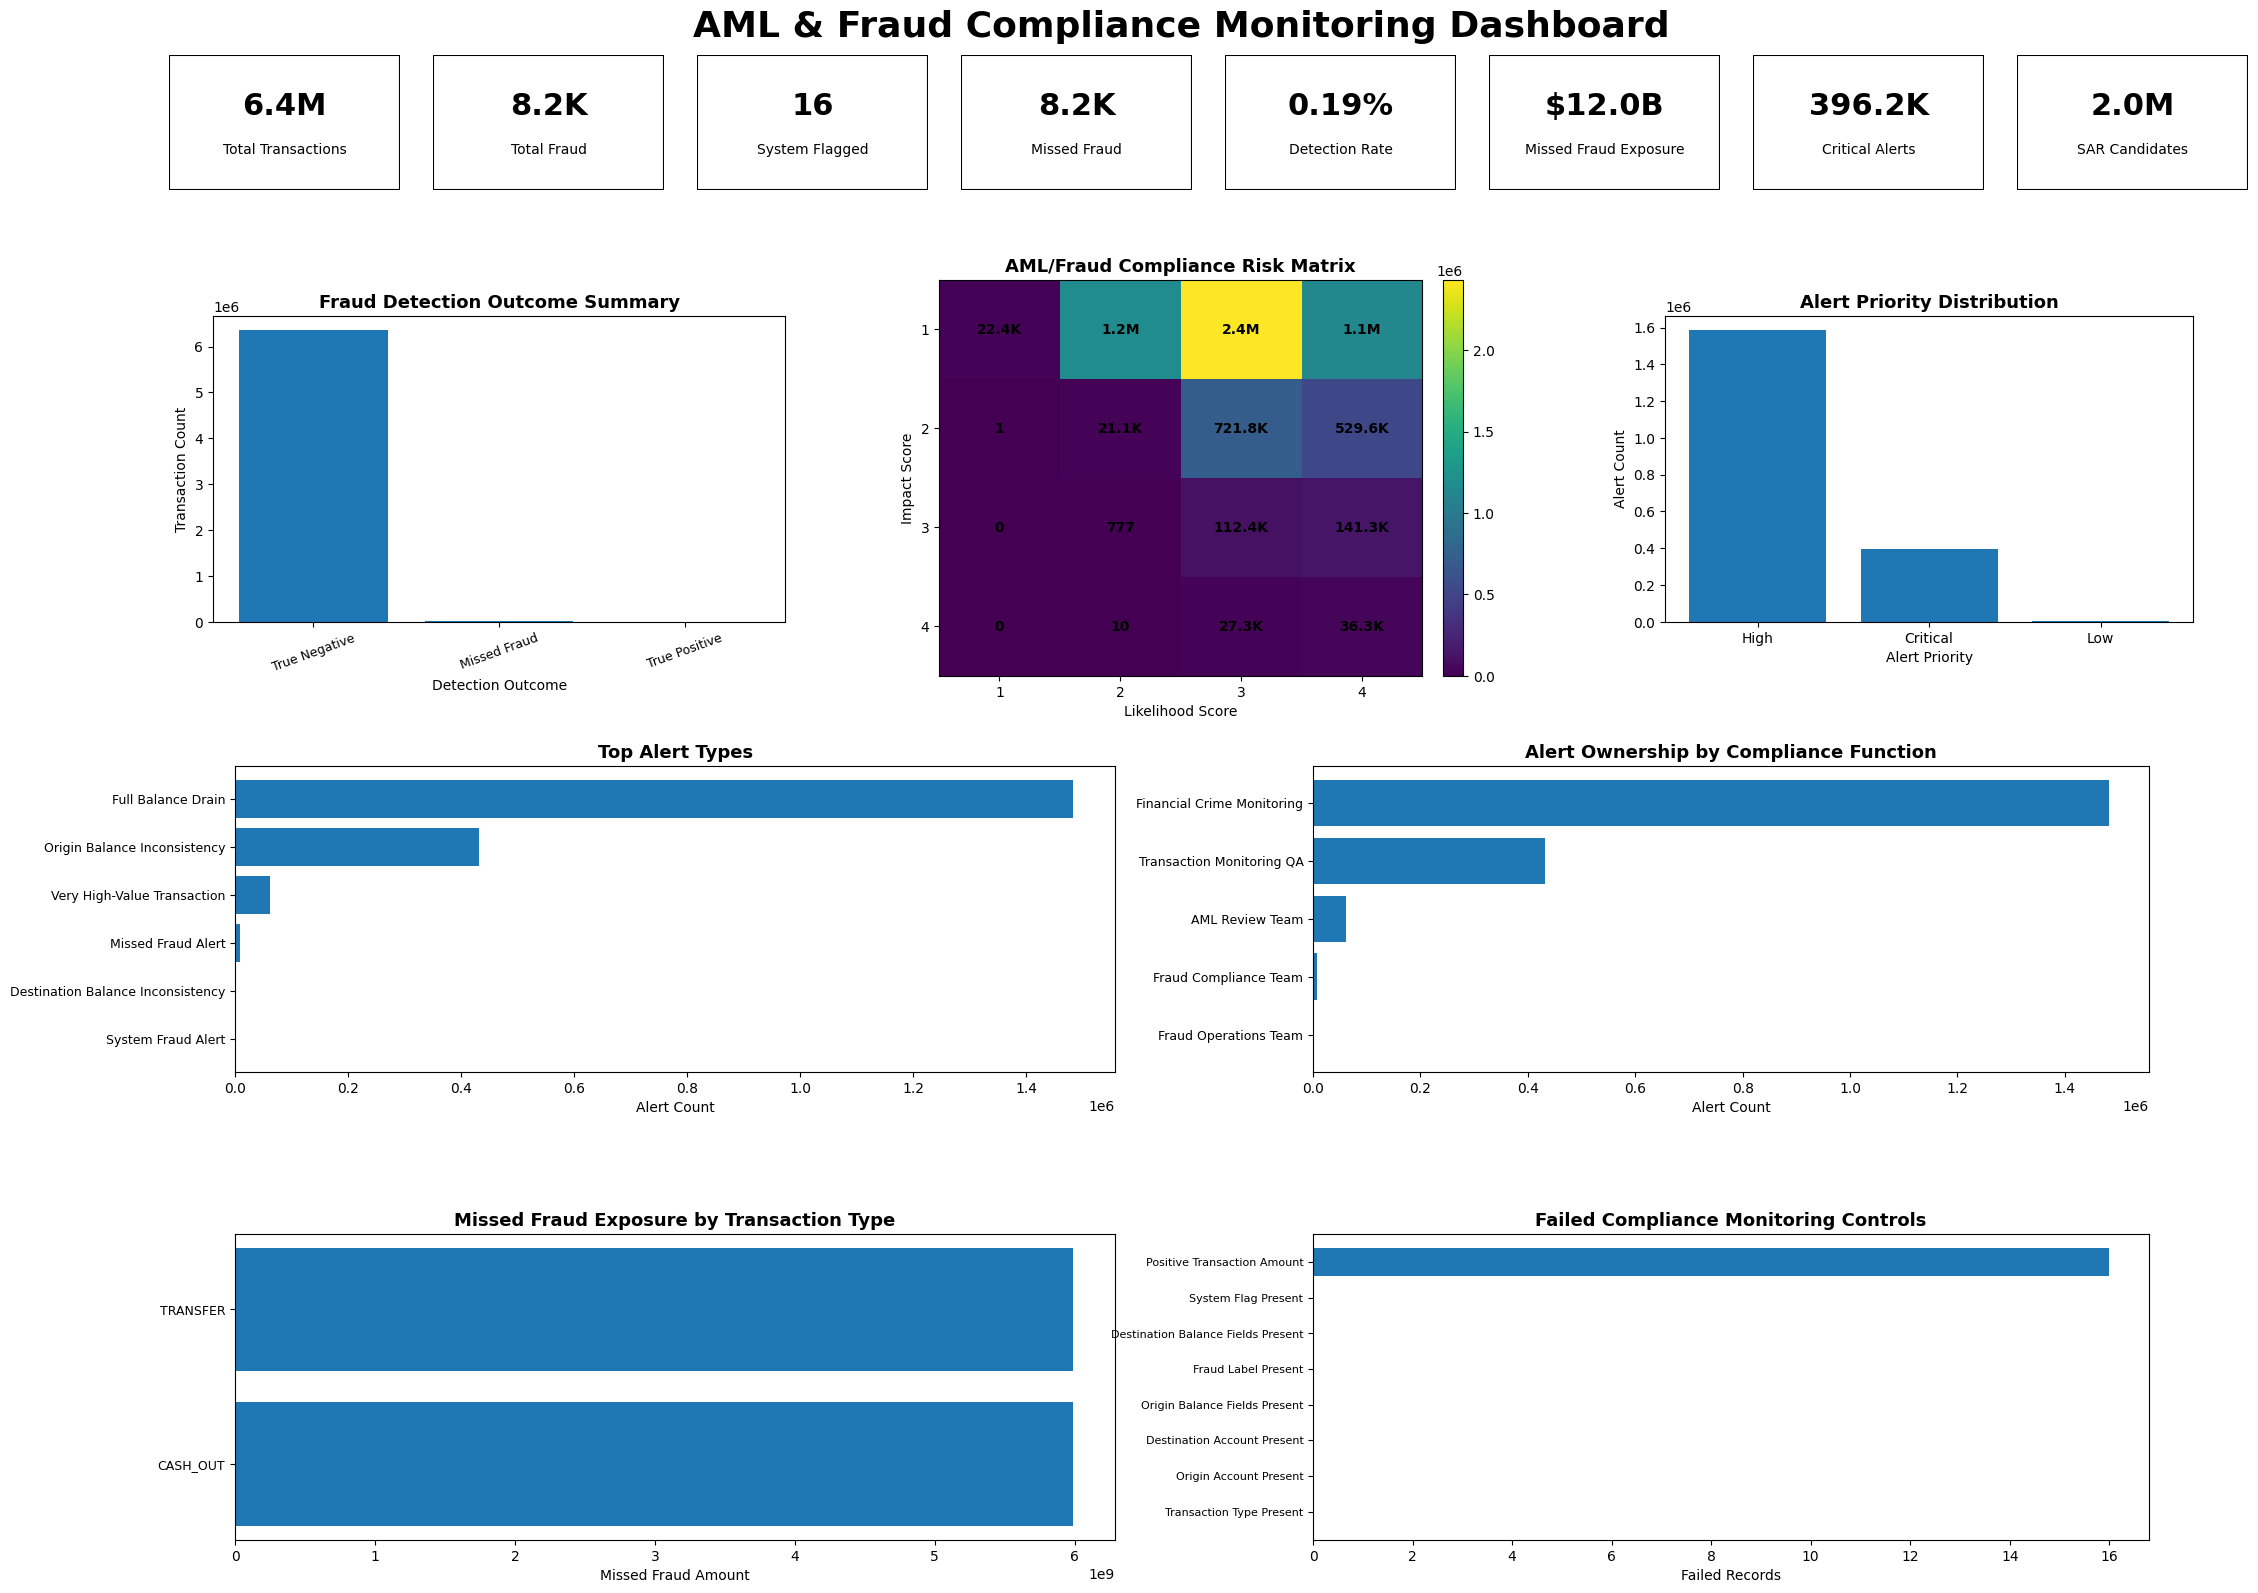

In [77]:
#dash
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

Path("outputs/charts").mkdir(parents=True, exist_ok=True)

# -----------------------------
# Helper formatting functions
# -----------------------------

def format_number(value):
    value = float(value)

    if abs(value) >= 1_000_000_000:
        return f"{value / 1_000_000_000:.1f}B"
    elif abs(value) >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    elif abs(value) >= 1_000:
        return f"{value / 1_000:.1f}K"
    else:
        return f"{value:,.0f}"


def format_currency(value):
    value = float(value)

    if abs(value) >= 1_000_000_000:
        return f"${value / 1_000_000_000:.1f}B"
    elif abs(value) >= 1_000_000:
        return f"${value / 1_000_000:.1f}M"
    elif abs(value) >= 1_000:
        return f"${value / 1_000:.1f}K"
    else:
        return f"${value:,.0f}"


def create_kpi_card(ax, title, value, subtitle=None):
    ax.axis("off")

    rect = plt.Rectangle(
        (0, 0),
        1,
        1,
        fill=False,
        linewidth=1.5,
        transform=ax.transAxes
    )
    ax.add_patch(rect)

    ax.text(
        0.5,
        0.62,
        str(value),
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.30,
        title,
        ha="center",
        va="center",
        fontsize=10,
        wrap=True
    )

    if subtitle:
        ax.text(
            0.5,
            0.12,
            subtitle,
            ha="center",
            va="center",
            fontsize=8
        )


# -----------------------------
# KPI calculations
# -----------------------------

total_transactions = len(df)
total_fraud = int(df["isFraud"].sum())
system_flagged = int(df["isFlaggedFraud"].sum())

missed_fraud = len(
    df[
        (df["isFraud"] == 1) &
        (df["isFlaggedFraud"] == 0)
    ]
)

critical_alerts = len(
    alert_register[
        alert_register["alert_priority"] == "Critical"
    ]
)

sar_candidate_count = len(sar_candidates)

detection_rate = round(
    (system_flagged / total_fraud) * 100,
    2
) if total_fraud > 0 else 0

missed_fraud_exposure = round(
    missed_fraud_df["amount"].sum(),
    2
)

# -----------------------------
# Pre-build chart data
# -----------------------------

detection_counts = (
    df["fraud_detection_outcome"]
    .value_counts()
)

priority_counts = (
    alert_register["alert_priority"]
    .value_counts()
)

alert_type_counts = (
    alert_register["alert_type"]
    .value_counts()
    .head(6)
    .sort_values(ascending=True)
)

owner_counts = (
    alert_register["alert_owner"]
    .value_counts()
    .sort_values(ascending=True)
)

missed_fraud_type_amount = (
    missed_fraud_df
    .groupby("type")["amount"]
    .sum()
    .sort_values(ascending=True)
)

failed_control_chart = (
    control_summary_df
    .sort_values("Failed", ascending=True)
)

# Shorten long control labels
failed_control_chart = failed_control_chart.copy()
failed_control_chart["Short Control"] = (
    failed_control_chart["Control"]
    .str.replace("CTRL-001 ", "", regex=False)
    .str.replace("CTRL-002 ", "", regex=False)
    .str.replace("CTRL-003 ", "", regex=False)
    .str.replace("CTRL-004 ", "", regex=False)
    .str.replace("CTRL-005 ", "", regex=False)
    .str.replace("CTRL-006 ", "", regex=False)
    .str.replace("CTRL-007 ", "", regex=False)
    .str.replace("CTRL-008 ", "", regex=False)
)

# -----------------------------
# Create dashboard canvas
# -----------------------------

fig = plt.figure(figsize=(22, 18))

fig.suptitle(
    "AML & Fraud Compliance Monitoring Dashboard",
    fontsize=26,
    fontweight="bold",
    y=0.98
)

# -----------------------------
# KPI cards - wider, more readable
# -----------------------------

kpi_positions = [
    [0.04, 0.88, 0.105, 0.075],
    [0.16, 0.88, 0.105, 0.075],
    [0.28, 0.88, 0.105, 0.075],
    [0.40, 0.88, 0.105, 0.075],
    [0.52, 0.88, 0.105, 0.075],
    [0.64, 0.88, 0.105, 0.075],
    [0.76, 0.88, 0.105, 0.075],
    [0.88, 0.88, 0.105, 0.075]
]

kpi_values = [
    ("Total Transactions", format_number(total_transactions), None),
    ("Total Fraud", format_number(total_fraud), None),
    ("System Flagged", format_number(system_flagged), None),
    ("Missed Fraud", format_number(missed_fraud), None),
    ("Detection Rate", f"{detection_rate}%", None),
    ("Missed Fraud Exposure", format_currency(missed_fraud_exposure), None),
    ("Critical Alerts", format_number(critical_alerts), None),
    ("SAR Candidates", format_number(sar_candidate_count), None)
]

for pos, item in zip(kpi_positions, kpi_values):
    ax = fig.add_axes(pos)
    create_kpi_card(ax, item[0], item[1], item[2])


# -----------------------------
# Row 1 charts
# -----------------------------

ax1 = fig.add_axes([0.06, 0.64, 0.26, 0.17])

ax1.bar(
    detection_counts.index,
    detection_counts.values
)

ax1.set_title("Fraud Detection Outcome Summary", fontsize=13, fontweight="bold")
ax1.set_xlabel("Detection Outcome")
ax1.set_ylabel("Transaction Count")
ax1.tick_params(axis="x", rotation=20, labelsize=9)


ax2 = fig.add_axes([0.39, 0.61, 0.24, 0.22])

matrix_plot = ax2.imshow(
    aml_risk_matrix,
    aspect="auto"
)

for i in range(aml_risk_matrix.shape[0]):
    for j in range(aml_risk_matrix.shape[1]):
        ax2.text(
            j,
            i,
            format_number(aml_risk_matrix.iloc[i, j]),
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

ax2.set_xticks(range(4))
ax2.set_xticklabels(["1", "2", "3", "4"])
ax2.set_yticks(range(4))
ax2.set_yticklabels(["1", "2", "3", "4"])
ax2.set_xlabel("Likelihood Score")
ax2.set_ylabel("Impact Score")
ax2.set_title("AML/Fraud Compliance Risk Matrix", fontsize=13, fontweight="bold")

fig.colorbar(
    matrix_plot,
    ax=ax2,
    fraction=0.045,
    pad=0.04
)


ax3 = fig.add_axes([0.72, 0.64, 0.24, 0.17])

ax3.bar(
    priority_counts.index,
    priority_counts.values
)

ax3.set_title("Alert Priority Distribution", fontsize=13, fontweight="bold")
ax3.set_xlabel("Alert Priority")
ax3.set_ylabel("Alert Count")


# -----------------------------
# Row 2 charts
# -----------------------------

ax4 = fig.add_axes([0.07, 0.39, 0.40, 0.17])

ax4.barh(
    alert_type_counts.index,
    alert_type_counts.values
)

ax4.set_title("Top Alert Types", fontsize=13, fontweight="bold")
ax4.set_xlabel("Alert Count")
ax4.tick_params(axis="y", labelsize=9)


ax5 = fig.add_axes([0.56, 0.39, 0.38, 0.17])

ax5.barh(
    owner_counts.index,
    owner_counts.values
)

ax5.set_title("Alert Ownership by Compliance Function", fontsize=13, fontweight="bold")
ax5.set_xlabel("Alert Count")
ax5.tick_params(axis="y", labelsize=9)


# -----------------------------
# Row 3 charts
# -----------------------------

ax6 = fig.add_axes([0.07, 0.13, 0.40, 0.17])

ax6.barh(
    missed_fraud_type_amount.index,
    missed_fraud_type_amount.values
)

ax6.set_title("Missed Fraud Exposure by Transaction Type", fontsize=13, fontweight="bold")
ax6.set_xlabel("Missed Fraud Amount")
ax6.tick_params(axis="y", labelsize=9)


ax7 = fig.add_axes([0.56, 0.13, 0.38, 0.17])

ax7.barh(
    failed_control_chart["Short Control"],
    failed_control_chart["Failed"]
)

ax7.set_title("Failed Compliance Monitoring Controls", fontsize=13, fontweight="bold")
ax7.set_xlabel("Failed Records")
ax7.tick_params(axis="y", labelsize=8)

# -----------------------------
# Save and show
# -----------------------------

plt.savefig(
    "outputs/charts/aml_fraud_compliance_dashboard_clean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Executive Dashboard Summary

The AML & Fraud Compliance Monitoring Dashboard provides an executive-level view of transaction monitoring performance, fraud exposure, alert prioritization, suspicious activity review candidates, and compliance control effectiveness.

The dashboard consolidates key governance and compliance metrics, including total transactions, actual fraud transactions, system-flagged fraud, missed fraud, detection rate, missed fraud exposure, critical alerts, and suspicious activity review candidates.

The fraud detection outcome summary compares actual fraud against system-generated fraud flags to identify true positives, missed fraud, false positives, and true negatives. This supports monitoring quality assurance and fraud control effectiveness reviews.

The AML/Fraud Compliance Risk Matrix evaluates transactions using impact and likelihood scoring to identify high-risk transaction concentrations requiring enhanced review.

The alert priority and alert ownership views simulate an enterprise compliance workflow by showing how suspicious transactions are prioritized and assigned to compliance teams.

The missed fraud exposure analysis highlights fraud transactions that were not flagged by the system, representing potential monitoring gaps and areas for rule enhancement.

Overall, this dashboard supports AML compliance monitoring, fraud risk oversight, suspicious activity review, audit readiness, and executive decision-making.

---